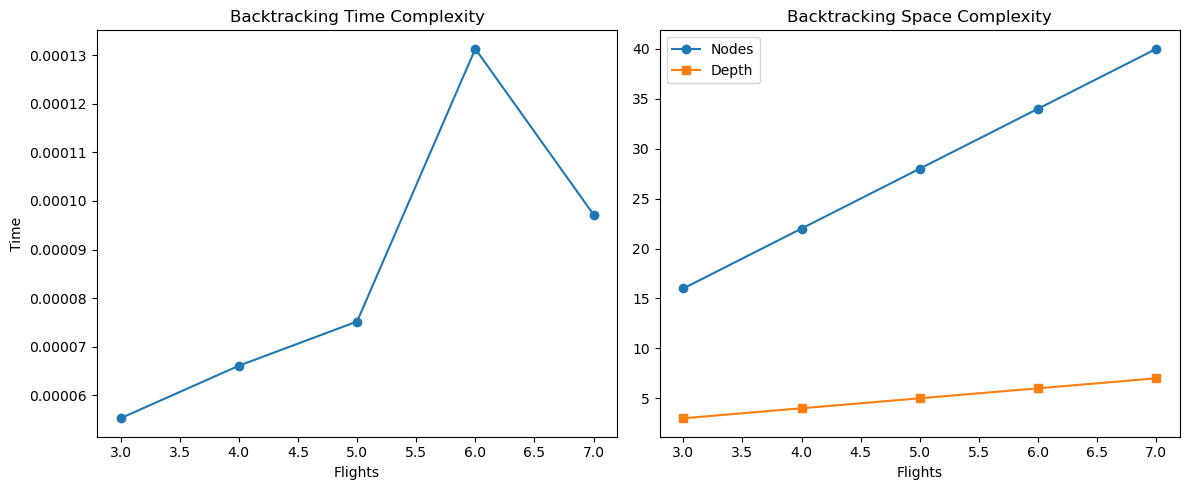

In [6]:
#Task 1: Backtracking Algorithms
import time
import matplotlib.pyplot as plt
# Problem setup
crew_members = ['C1', 'C2', 'C3']
REST_TIME = 1
""" tasks 1 and 2 combine:
    - Backtracking → explores all valid assignments
    - Branch & Bound → avoids exploring bad solutions"""
    
def generate_flights(n):
    flights = []
    start = 8
    for i in range(n):
        flights.append((f'F{i+1}', start + i, start + i + 2))
    return flights
def is_valid_assignment(crew_schedule, new_flight):
    new_start, new_end = new_flight[1], new_flight[2]
    for assigned in crew_schedule:
        ass_start, ass_end = assigned[1], assigned[2]
        if not (new_end + REST_TIME <= ass_start or new_start >= ass_end + REST_TIME):
            return False
    return True

def get_crew_load(flights):
    return sum(f[2] - f[1] for f in flights)

# Pure Backtracking
def backtracking(flight_idx, current_schedule, flights):
    global node_count, max_depth

    node_count += 1
    max_depth = max(max_depth, flight_idx)

    if flight_idx == len(flights):
        return

    current_flight = flights[flight_idx]

    for crew in crew_members:
        if is_valid_assignment(current_schedule[crew], current_flight):
            current_schedule[crew].append(current_flight)
            backtracking(flight_idx + 1, current_schedule, flights)
            current_schedule[crew].pop()

# Experiment
sizes = [3, 4, 5, 6, 7]
times_bt = []
nodes_bt = []
depths_bt = []

for size in sizes:
    flights = generate_flights(size)
    node_count = 0
    max_depth = 0
    schedule = {c: [] for c in crew_members}
    start = time.perf_counter()
    backtracking(0, schedule, flights)
    end = time.perf_counter()
    times_bt.append(end - start)
    nodes_bt.append(node_count)
    depths_bt.append(max_depth)

# Plot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(sizes, times_bt, marker='o')
plt.title("Backtracking Time Complexity")
plt.xlabel("Flights")
plt.ylabel("Time")
plt.subplot(1,2,2)
plt.plot(sizes, nodes_bt, marker='o', label='Nodes')
plt.plot(sizes, depths_bt, marker='s', label='Depth')
plt.title("Backtracking Space Complexity")
plt.xlabel("Flights")
plt.legend()
plt.tight_layout()
plt.show()

Optimal Maximum Load Achieved: 4 hours
--- Best Load-Balanced Schedule ---
C1 (Total Work: 4 hrs): [('F1', 8, 10), ('F3', 11, 13)]
C2 (Total Work: 4 hrs): [('F2', 9, 11), ('F5', 14, 16)]
C3 (Total Work: 4 hrs): [('F4', 12, 14), ('F6', 15, 17)]


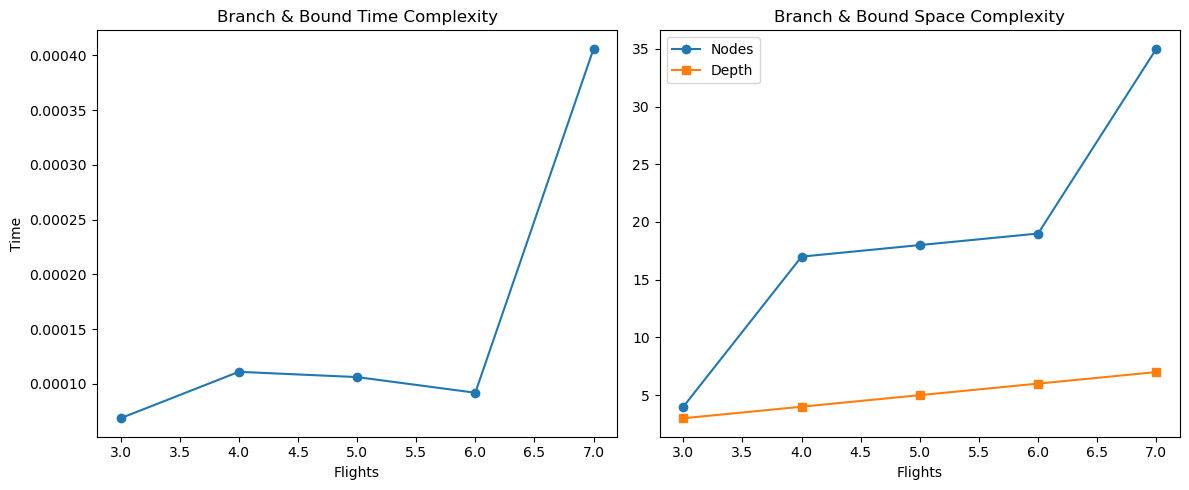

In [7]:
#Task 2: Branch and Bound Algorithms
crew_members = ['C1', 'C2', 'C3']
REST_TIME = 1
    """Bounding Idea:
    If a partial solution is already worse than the best found,
     exploring that branch is stopped(pruning).
    """
#  Original Flights (for final output) 
original_flights = [
    ('F1', 8, 10), ('F2', 9, 11), ('F3', 11, 13),
    ('F4', 12, 14), ('F5', 14, 16), ('F6', 15, 17)
]

#  Helper Functions 
def generate_flights(n):
    flights = []
    start = 8
    for i in range(n):
        flights.append((f'F{i+1}', start + i, start + i + 2))
    return flights

def is_valid_assignment(crew_schedule, new_flight):
    new_start, new_end = new_flight[1], new_flight[2]
    for assigned in crew_schedule:
        ass_start, ass_end = assigned[1], assigned[2]
        if not (new_end + REST_TIME <= ass_start or new_start >= ass_end + REST_TIME):
            return False
    return True

def get_crew_load(flights):
    return sum(f[2] - f[1] for f in flights)

#  Branch & Bound 
def branch_and_bound(flight_idx, current_schedule, flights):
    global min_max_load, best_schedule
    global node_count, max_depth

    node_count += 1
    max_depth = max(max_depth, flight_idx)

    if flight_idx == len(flights):
        current_max = max(get_crew_load(v) for v in current_schedule.values())

        if current_max < min_max_load:
            min_max_load = current_max
            best_schedule = {k: list(v) for k, v in current_schedule.items()}
        return

    current_flight = flights[flight_idx]
    duration = current_flight[2] - current_flight[1]

    for crew in crew_members:
        if is_valid_assignment(current_schedule[crew], current_flight):

            potential = get_crew_load(current_schedule[crew]) + duration

            if potential >= min_max_load:
                continue

            current_schedule[crew].append(current_flight)
            branch_and_bound(flight_idx + 1, current_schedule, flights)
            current_schedule[crew].pop()

# FINAL OUTPUT

min_max_load = float('inf')
best_schedule = None
schedule = {c: [] for c in crew_members}
branch_and_bound(0, schedule, original_flights)
print(f"Optimal Maximum Load Achieved: {min_max_load} hours")
print("--- Best Load-Balanced Schedule ---")

for crew, f_list in best_schedule.items():
    print(f"{crew} (Total Work: {get_crew_load(f_list)} hrs): {f_list}")

# COMPLEXITY ANALYSIS

sizes = [3, 4, 5, 6, 7]
times_bb = []
nodes_bb = []
depths_bb = []

for size in sizes:
    flights = generate_flights(size)
    min_max_load = float('inf')
    best_schedule = None
    node_count = 0
    max_depth = 0
    schedule = {c: [] for c in crew_members}
    start = time.perf_counter()
    branch_and_bound(0, schedule, flights)
    end = time.perf_counter()
    times_bb.append(end - start)
    nodes_bb.append(node_count)
    depths_bb.append(max_depth)

#plotting
plt.figure(figsize=(12,5))
# Time Complexity
plt.subplot(1,2,1)
plt.plot(sizes, times_bb, marker='o')
plt.title("Branch & Bound Time Complexity")
plt.xlabel("Flights")
plt.ylabel("Time")
# Space Complexity
plt.subplot(1,2,2)
plt.plot(sizes, nodes_bb, marker='o', label='Nodes')
plt.plot(sizes, depths_bb, marker='s', label='Depth')
plt.title("Branch & Bound Space Complexity")
plt.xlabel("Flights")
plt.legend()

plt.tight_layout()
plt.show()

Running Task 3 Analysis...


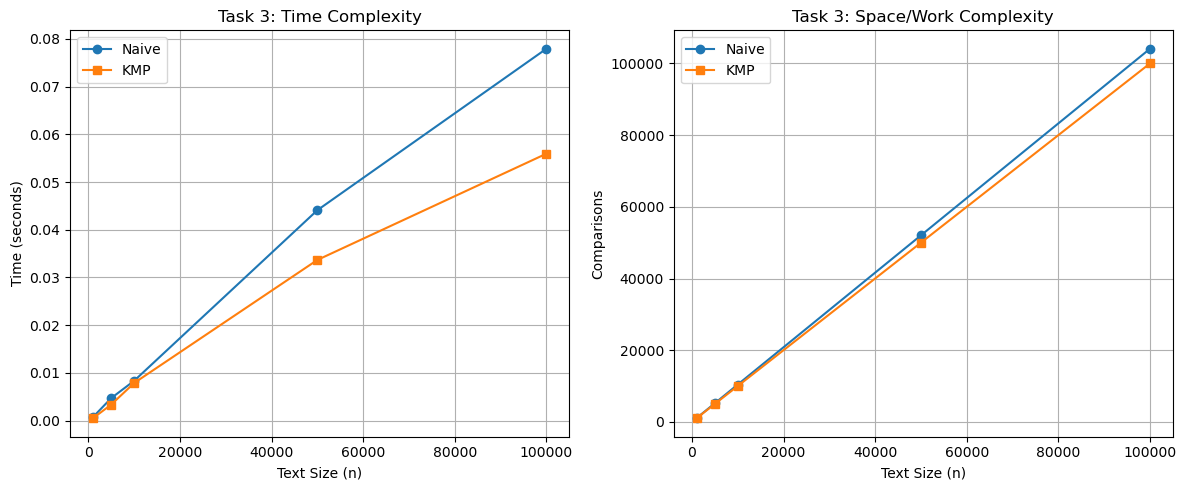

In [5]:
import time
import random
import string
#Task 3: Algorithm Implementations 
"""
    Naive approach checks pattern at every position.
    Time Complexity:
    Worst case = O(n * m)
    Idea:
    Brute-force comparison without optimization.
"""
def naive_search(pattern, text):
    comparisons = 0
    m, n = len(pattern), len(text)
    occurrences = []
    for i in range(n - m + 1):
        match = True
        for j in range(m):
            comparisons += 1
            if text[i + j] != pattern[j]:
                match = False
                break
        if match:
            occurrences.append(i)
    return occurrences, comparisons
"""
    CONCEPT:
    LPS (Longest Prefix Suffix) array stores:
    longest prefix = suffix for each index
    This allows KMP to skip redundant comparisons.
"""
def compute_lps(pattern):
    m = len(pattern)
    lps = [0] * m
    length = 0
    i = 1
    while i < m:
        if pattern[i] == pattern[length]:
            length += 1
            lps[i] = length
            i += 1
        else:
            if length != 0:
                length = lps[length - 1]
            else:
                lps[i] = 0
                i += 1
    return lps
def kmp_search(pattern, text):
    comparisons = 0
    m, n = len(pattern), len(text)
    lps = compute_lps(pattern)
    occurrences = []
    i = j = 0
    while i < n:
        comparisons += 1
        if pattern[j] == text[i]:
            i += 1
            j += 1
        if j == m:
            occurrences.append(i - j)
            j = lps[j - 1]
        elif i < n and pattern[j] != text[i]:
            if j != 0:
                j = lps[j - 1]
            else:
                i += 1

    return occurrences, comparisons


#Complexity Experiment 

text_sizes = [1000, 5000, 10000, 50000, 100000]
pattern = "ABCABD"
naive_times, kmp_times = [], []
naive_comps, kmp_comps = [], []
print("Running Task 3 Analysis...")

for size in text_sizes:
    text = ''.join(random.choices(string.ascii_uppercase, k=size))
    text = text[:size//2] + pattern + text[size//2:]
    # Naive
    start = time.perf_counter()
    _, comps = naive_search(pattern, text)
    naive_times.append(time.perf_counter() - start)
    naive_comps.append(comps)
    # KMP
    start = time.perf_counter()
    _, comps = kmp_search(pattern, text)
    kmp_times.append(time.perf_counter() - start)
    kmp_comps.append(comps)


# Plotting Time & Space Complexity 
plt.figure(figsize=(12,5))
# Time Complexity
plt.subplot(1,2,1)
plt.plot(text_sizes, naive_times, marker='o')
plt.plot(text_sizes, kmp_times, marker='s')
plt.title("Task 3: Time Complexity")
plt.xlabel("Text Size (n)")
plt.ylabel("Time (seconds)")
plt.legend(['Naive', 'KMP'])
plt.grid()D
#  Space / Work Complexity (via comparisons)
plt.subplot(1,2,2)
plt.plot(text_sizes, naive_comps, marker='o')
plt.plot(text_sizes, kmp_comps, marker='s')
plt.title("Task 3: Space/Work Complexity")
plt.xlabel("Text Size (n)")
plt.ylabel("Comparisons")
plt.legend(['Naive', 'KMP'])
plt.grid()

plt.tight_layout()
plt.show()

Running Profiling... Please wait.


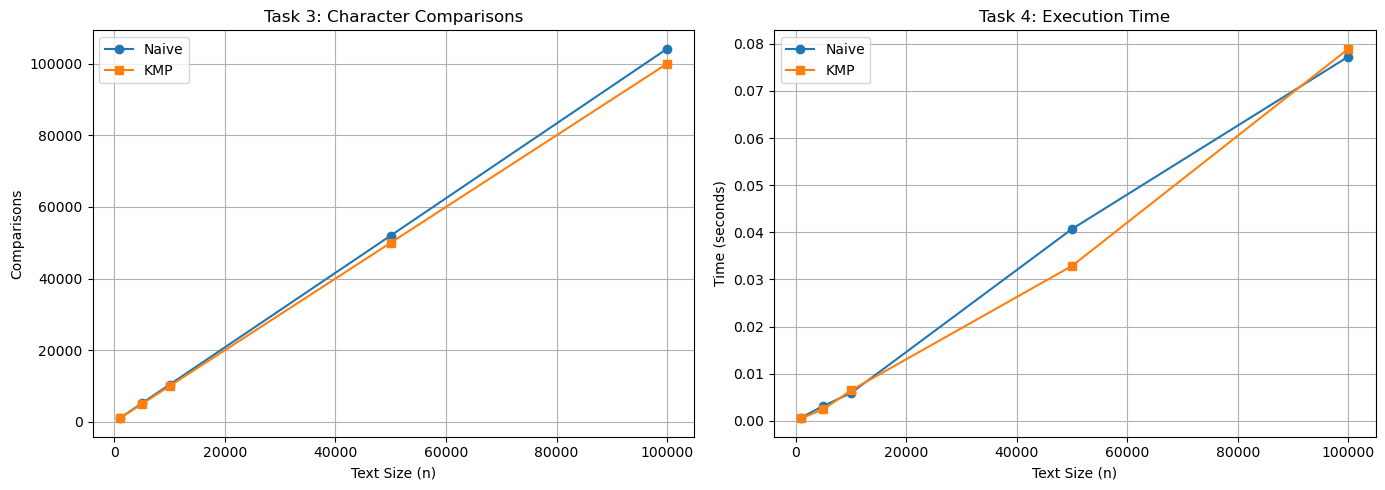

In [2]:
# --- Task 4: Experimental Comparison ---
"""
CONCEPT:
We empirically compare:
1. Execution Time (actual running time)
2. Number of Comparisons (work done → proxy for space/effort)
Goal:
Validate theoretical complexity using graphs.
"""
text_sizes = [1000, 5000, 10000, 50000, 100000]
pattern = "ABCABD"
naive_times, kmp_times = [], []
naive_comps, kmp_comps = [], []
print("Running Profiling... Please wait.")

for size in text_sizes:
    # Generate random text and insert pattern
    text = ''.join(random.choices(string.ascii_uppercase, k=size))
    text = text[:size//2] + pattern + text[size//2:]

    # Naive Search
    start = time.perf_counter()
    _, comps = naive_search(pattern, text)
    naive_times.append(time.perf_counter() - start)
    naive_comps.append(comps)

    # KMP Search
    start = time.perf_counter()
    _, comps = kmp_search(pattern, text)
    kmp_times.append(time.perf_counter() - start)
    kmp_comps.append(comps)

# --- Plotting ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# Character Comparisons
ax1.plot(text_sizes, naive_comps, marker='o')
ax1.plot(text_sizes, kmp_comps, marker='s')
ax1.set_title('Task 3: Character Comparisons')
ax1.set_xlabel('Text Size (n)')
ax1.set_ylabel('Comparisons')
ax1.grid()
ax1.legend(['Naive', 'KMP'])
"""
Graphs show:
- Time Complexity → actual runtime growth
- Work Complexity → number of comparisons
"""
# Execution Time
ax2.plot(text_sizes, naive_times, marker='o')
ax2.plot(text_sizes, kmp_times, marker='s')
ax2.set_title('Task 4: Execution Time')
ax2.set_xlabel('Text Size (n)')
ax2.set_ylabel('Time (seconds)')
ax2.grid()
ax2.legend(['Naive', 'KMP'])

plt.tight_layout()
plt.show()